# Task 6: Lane Detection using Hough Lines

**Lab 06 solution**  
Run cells from top to bottom. Change only the paths in the configuration cell when using your own media.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def show(img, title='', cmap=None, size=(12,7)):
    plt.figure(figsize=size)
    if img.ndim == 3:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap or 'gray')
    plt.title(title); plt.axis('off'); plt.show()

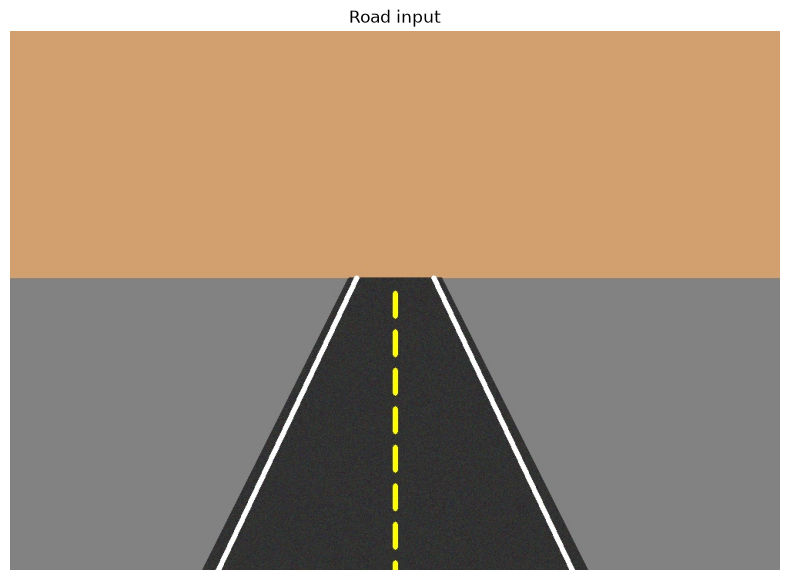

Image width: 1000
Image height: 700


In [8]:
# ============================================================
# CELL: Load Road Image
# ============================================================

IMAGE_PATH = 'road.jpg'


# ============================================================
# Load Image
# ============================================================

img = cv.imread(
    IMAGE_PATH
)


# ============================================================
# Validate Image
# ============================================================

if img is None:

    raise FileNotFoundError(
        f"Image not found: {IMAGE_PATH}"
    )


# ============================================================
# Get Image Dimensions
# ============================================================

H, W = img.shape[:2]


# ============================================================
# Display Input Image
# ============================================================

show(
    img,
    'Road input'
)


# ============================================================
# Print Image Information
# ============================================================

print(
    'Image width:',
    W
)

print(
    'Image height:',
    H
)


In [4]:
# ============================================================
# Hough Line Detection inside ROI
# ============================================================

# Create ROI mask
mask = np.zeros_like(edges)

cv.fillPoly(
    mask,
    roi,
    255
)

roi_edges = cv.bitwise_and(
    edges,
    mask
)


# ============================================================
# Detect line segments
# ============================================================

lines = cv.HoughLinesP(
    roi_edges,
    1,
    np.pi / 180,
    threshold=45,
    minLineLength=40,
    maxLineGap=120
)


# ============================================================
# Separate left and right lane lines
# ============================================================

left = []
right = []

if lines is not None:

    # Handles both (N, 1, 4) and (N, 4)
    lines = lines.reshape(-1, 4)

    for x1, y1, x2, y2 in lines:

        # Ignore perfectly vertical lines
        if x2 == x1:
            continue

        slope = (
            (y2 - y1)
            / float(x2 - x1)
        )

        # Ignore lines that are too horizontal
        if abs(slope) < 0.45:
            continue

        # Positive slope → one side
        if slope > 0:
            left.append(
                (x1, y1, x2, y2)
            )

        # Negative slope → other side
        else:
            right.append(
                (x1, y1, x2, y2)
            )


print(
    "Left line candidates:",
    len(left)
)

print(
    "Right line candidates:",
    len(right)
)


Left line candidates: 6
Right line candidates: 5


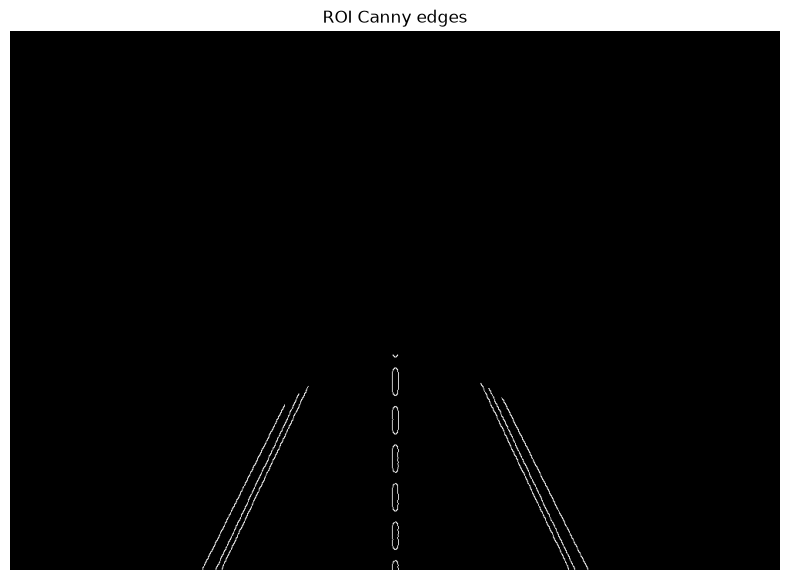

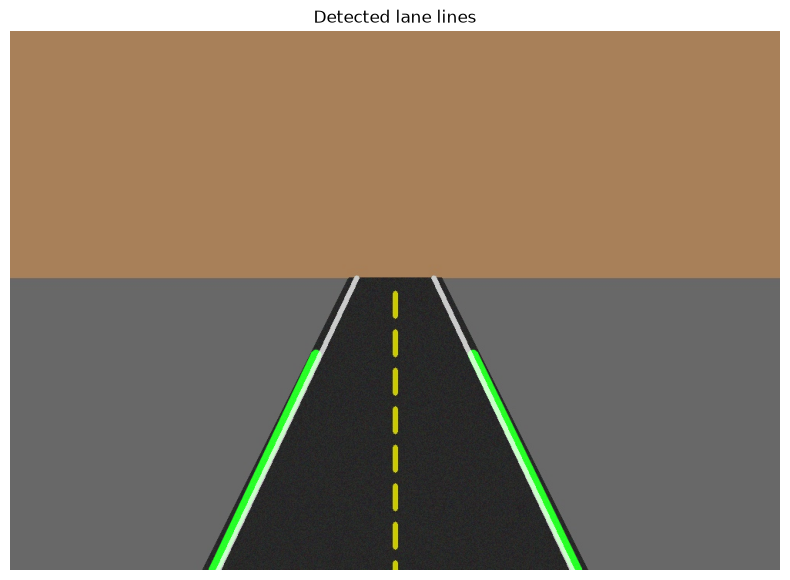

Left segments: 6
Right segments: 5
Left extrapolated line: (736, 700, 601, 420)
Right extrapolated line: (264, 700, 397, 420)


In [ ]:
# ============================================================
# Extrapolate and Draw Detected Lane Lines
# ============================================================

def line_parameters(lines):
    """
    Convert Hough line segments
    (x1, y1, x2, y2)
    into slope/intercept pairs
    (m, b).
    """

    params = []

    for x1, y1, x2, y2 in lines:

        # Avoid vertical lines
        if x2 == x1:
            continue

        m = (
            (y2 - y1)
            / float(x2 - x1)
        )

        # Ignore nearly horizontal lines
        if abs(m) < 1e-6:
            continue

        b = y1 - m * x1

        params.append(
            (m, b)
        )

    return params


def extrapolate(lines):

    # Convert Hough segments to (slope, intercept)
    params = line_parameters(lines)

    if not params:
        return None

    # Average slope and intercept
    m, b = np.mean(
        params,
        axis=0
    )

    # Avoid division by zero
    if abs(m) < 1e-6:
        return None

    # Extend line from bottom of image
    # to 60% of image height
    y1 = H
    y2 = int(0.60 * H)

    x1 = int(
        (y1 - b) / m
    )

    x2 = int(
        (y2 - b) / m
    )

    return (
        x1,
        y1,
        x2,
        y2
    )


# ============================================================
# Calculate Extrapolated Lane Lines
# ============================================================

left_line = extrapolate(
    left
)

right_line = extrapolate(
    right
)


# ============================================================
# Create Output Image
# ============================================================

result = img.copy()

overlay = np.zeros_like(
    img
)


# ============================================================
# Draw Left Lane
# ============================================================

if left_line is not None:

    cv.line(
        overlay,
        left_line[:2],
        left_line[2:],
        (0, 255, 0),
        12,
        cv.LINE_AA
    )


# ============================================================
# Draw Right Lane
# ============================================================

if right_line is not None:

    cv.line(
        overlay,
        right_line[:2],
        right_line[2:],
        (0, 255, 0),
        12,
        cv.LINE_AA
    )


# ============================================================
# Combine Overlay with Original Image
# ============================================================

result = cv.addWeighted(
    result,
    0.8,
    overlay,
    1.0,
    0
)


# ============================================================
# Display Results
# ============================================================

show(
    roi_edges,
    'ROI Canny edges'
)

show(
    result,
    'Detected lane lines'
)


# ============================================================
# Save Result
# ============================================================

cv.imwrite(
    'task6_lane_detection.jpg',
    result
)


# ============================================================
# Print Results
# ============================================================

print(
    'Left segments:',
    len(left)
)

print(
    'Right segments:',
    len(right)
)

print(
    'Left extrapolated line:',
    left_line
)

print(
    'Right extrapolated line:',
    right_line
)


## Interpretation
The trapezoidal ROI suppresses sky, buildings, and nearby roadside edges. Hough segments are classified by slope, averaged, and extrapolated. Curved roads need a polynomial/sliding-window method rather than a single straight line per lane.